In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalPrice,PurchaseHour,DayOfWeek,Year,Month,Day,Weekday,Hour,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday,2009,12,1,Tuesday,7,4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,2009,12,1,Tuesday,7,4
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,2009,12,1,Tuesday,7,4
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday,2009,12,1,Tuesday,7,4
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday,2009,12,1,Tuesday,7,4


In [4]:
inventory = df.groupby("StockCode").agg({

    "Description":"first",

    "Quantity":"sum",

    "TotalPrice":"sum"

}).reset_index()

inventory.head()

,StockCode,Description,Quantity,TotalPrice
0,10002,INFLATABLE POLITICAL GLOBE,7796,6057.72
1,10080,GROOVY CACTUS INFLATABLE,12,10.20
2,10109,BENDY COLOUR PENCILS,4,1.68
3,10120,DOGGY RUBBER,471,98.91
4,10123C,HEARTS WRAPPING TAPE,624,224.16


In [5]:
days = (
    df["InvoiceDate"].max()
    -
    df["InvoiceDate"].min()
).days

inventory["Average_Daily_Demand"] = (
    inventory["Quantity"] / days
)

In [6]:
LEAD_TIME = 7

inventory["Lead_Time_Demand"] = (
    inventory["Average_Daily_Demand"] * LEAD_TIME
)

In [7]:
inventory["Safety_Stock"] = (
    inventory["Average_Daily_Demand"] * 3
)

In [8]:
inventory["Reorder_Point"] = (

    inventory["Lead_Time_Demand"]

    +

    inventory["Safety_Stock"]

)

In [9]:
np.random.seed(42)

inventory["Current_Stock"] = np.random.randint(
    10,
    500,
    len(inventory)
)

In [10]:
inventory["Reorder_Quantity"] = np.where(

    inventory["Current_Stock"]

    <

    inventory["Reorder_Point"],

    inventory["Reorder_Point"]

    -

    inventory["Current_Stock"],

    0

)

In [11]:
inventory["Status"] = np.where(

    inventory["Current_Stock"]

    <

    inventory["Reorder_Point"],

    "Reorder",

    "Sufficient"

)

In [12]:
inventory[[
    "StockCode",
    "Description",
    "Current_Stock",
    "Reorder_Point",
    "Reorder_Quantity",
    "Status"
]].head(20)

,StockCode,Description,Current_Stock,Reorder_Point,Reorder_Quantity,Status
0,10002,INFLATABLE POLITICAL GLOBE,112,209.008043,97.008043,Reorder
1,10080,GROOVY CACTUS INFLATABLE,445,0.321716,0.000000,Sufficient
2,10109,BENDY COLOUR PENCILS,358,0.107239,0.000000,Sufficient
3,10120,DOGGY RUBBER,280,12.627346,0.000000,Sufficient
4,10123C,HEARTS WRAPPING TAPE,116,16.729223,0.000000,Sufficient
5,10123G,ARMY CAMO WRAPPING TAPE,81,60.214477,0.000000,Sufficient
6,10124A,SPOTS ON RED BOOKCOVER TAPE,198,1.233244,0.000000,Sufficient
7,10124G,ARMY CAMO BOOKCOVER TAPE,30,0.536193,0.000000,Sufficient
8,10125,MINI FUNKY DESIGN TAPES,112,21.126005,0.000000,Sufficient
9,10133,COLOURING PENCILS BROWN TUBE,131,25.924933,0.000000,Sufficient


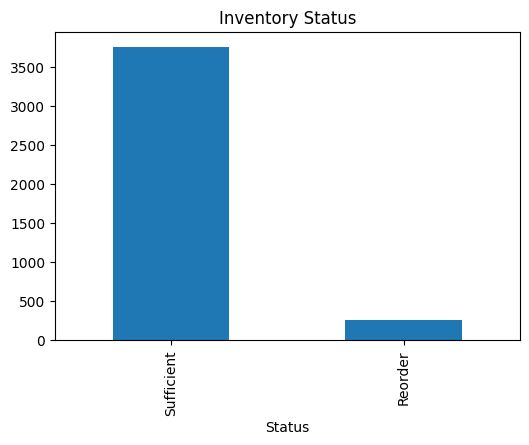

In [13]:
inventory["Status"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Inventory Status")

plt.show()

In [14]:
top_reorder = inventory.sort_values(

    "Reorder_Quantity",

    ascending=False

).head(20)

top_reorder[[
    "Description",
    "Reorder_Quantity"
]]

,Description,Reorder_Quantity
598,PACK OF 72 RETRO SPOT CAKE CASES,1410.689008
3481,WHITE HANGING HEART T-LIGHT HOLDER,1248.163539
3459,JUMBO BAG RED WHITE SPOTTY,1161.461126
2813,WORLD WAR 2 GLIDERS ASSTD DESIGNS,1090.075067
107,BROCADE RING PURSE,1067.313673
3220,ASSORTED COLOUR BIRD ORNAMENT,746.179625
599,PACK OF 72 SKULL CAKE CASES,645.630027
1219,PACK OF 12 SUKI TISSUES,566.849866
2967,GIRLS ALPHABET IRON ON PATCHES,536.557641
3339,60 TEATIME FAIRY CAKE CASES,472.924933


In [15]:
inventory.to_csv(
    "../data/processed/inventory_recommendations.csv",
    index=False
)